                               order_id  customer_id  product_id     category  \
0  b8ec9f86-5919-4b71-a5f7-945e7c0a3db0         2031         845        Books   
1  5ea92c47-c5b2-4bdd-8a50-d77efd77ec89         2350         995  Electronics   
2  5cc48ce0-2c6d-4448-af3f-96f8a910d45b         1818         997       Beauty   
3  74d5c0f4-53f0-4367-a5c5-baaa114c2d9f          472         385         Home   
4  7a630323-8ac8-406e-875a-4bcdead440ab         1075          31     Clothing   

    price  quantity                  order_date               shipping_date  \
0   45.95         4  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
1  403.17         3  2024-04-20 14:59:58.897063  2024-04-22 14:59:58.897063   
2  317.45         2  2024-04-20 14:59:58.897063  2024-04-27 14:59:58.897063   
3   24.08         3  2024-04-20 14:59:58.897063  2024-04-24 14:59:58.897063   
4  494.90         1  2024-04-20 14:59:58.897063  2024-04-25 14:59:58.897063   

  delivery_status payment_method devic

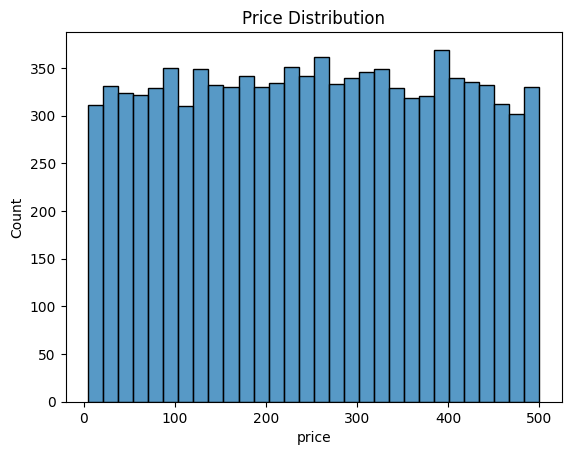

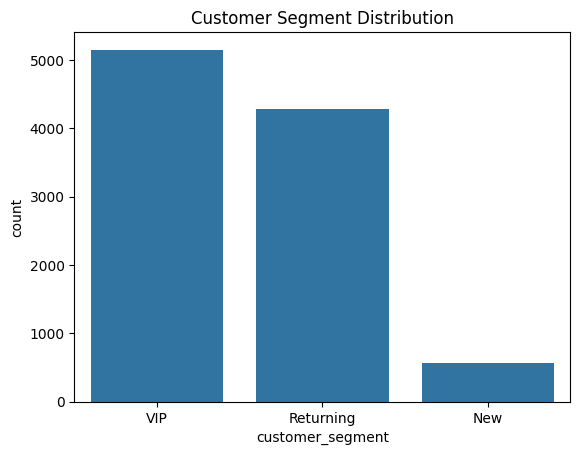

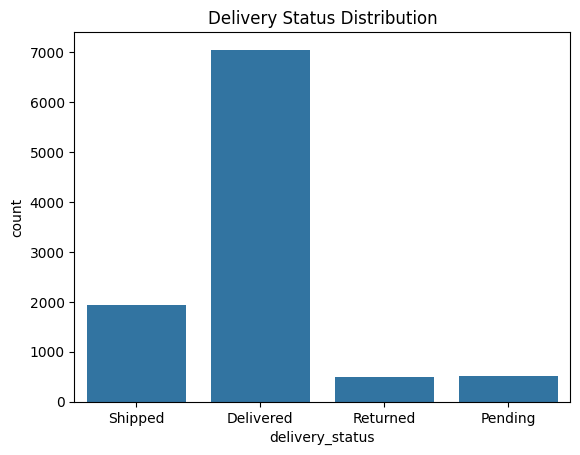

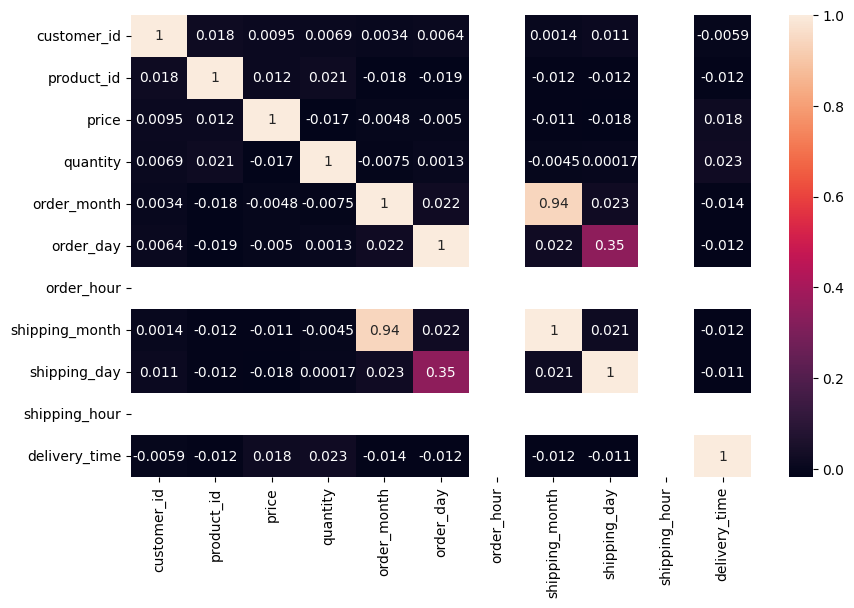

In [ ]:
import pandas as pd
import numpy as np
import matplotlib as plb
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------
# load unclear csv dataset 
# ---------------------------------------  
df = pd.read_csv("../data/ecommerce_order.csv")

print(df.head())

# ---------------------------------------
# drop useless columns 
# ---------------------------------------
df.drop([
    "order_id", "customer_id", "product_id", "shipping_address", "billing_address" 
], axis=1)

# ---------------------------------------
# convert dates
# ---------------------------------------
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df["shipping_date"] = pd.to_datetime(df["shipping_date"], errors="coerce")

# ---------------------------------------
# extract features
# ---------------------------------------
df["order_month"] = df["order_date"].dt.month
df["order_day"] = df["order_date"].dt.day
df["order_hour"] = df["order_date"].dt.hour

df["shipping_month"] = df["shipping_date"].dt.month
df["shipping_day"] = df["shipping_date"].dt.day
df["shipping_hour"] = df["shipping_date"].dt.hour

# ---------------------------------------
# create delivery delay feature
# ---------------------------------------
df["delivery_time"] = (df["shipping_date"] - df["order_date"]).dt.days

# ---------------------------------------
# remove invalid values
# ---------------------------------------
df = df[df["shipping_delay"] >= 0]

# ---------------------------------------
# drop null values
# ---------------------------------------
# ---------------------------------------
# create delivery delay feature
print(df.isnull().sum())
df = df.dropna()

# ---------------------------------------
# visualize price distributaion
# ---------------------------------------
sns.histplot(df["price"], bins=30)
plt.title("Price Distribution")
plt.show()

# ---------------------------------------
# customer segment distribution
# ---------------------------------------
sns.countplot(x="customer_segment", data=df)
plt.title("Customer Segment Distribution")
plt.show()

# ---------------------------------------
# delivery stauts distribution
# ---------------------------------------
sns.countplot(x="delivery_status", data=df)
plt.title("Delivery Status Distribution")
plt.show()

# ---------------------------------------
# Correlation Matrix
# ---------------------------------------
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True)
plt.show()

# ---------------------------------------
# build preprocessing pipeline
# ---------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

df.drop(columns=["price"])

categorical_features = [
    "category",
    "payment_method",
    "device_type",
    "channel"
]

numerical_features = [
    "quantity",
    "delivery_time",
    "order_month",
    "order_day"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


